In [118]:
%matplotlib inline
from sklearn.neural_network import MLPClassifier
import pandas as pd
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_curve, auc
import matplotlib.pyplot as plt

In [119]:
df = pd.read_table("Lab Files\\resources\\course3\\assets\\fruit_data_with_colors.txt")
X = df[df.columns[3:6]] # mass, width, height
y = df[df.columns[0]] # fruit_label

# using make classification
X, y = make_classification(n_samples=1000, n_features=20, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

In [120]:
df = pd.read_csv("Lab Files\\resources\\course3\\assets\\fraud_data.csv")
df.head(2)
X = df[df.columns[:-1]]
y = df[df.columns[-1]]
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=42)

## hidden_layer_sizes=[2, 2, 2, 2]
**means:** 4 layers with 2 units in each

In [ ]:
mlp_clf = MLPClassifier(solver='lbfgs', activation='tanh', hidden_layer_sizes=[2, 2, 2, 2]).fit(X_train, y_train)
y_pred = mlp_clf.predict(X_test)
y_scores = mlp_clf.predict_proba(X_test)[:,1]

c:\Users\shurai\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [122]:
accuracy_score(y_test, y_pred)

0.9966814159292036

In [123]:
fpr, tpr, _ = roc_curve(y_test, y_scores)
auc(fpr, tpr)

np.float64(0.946675298836236)

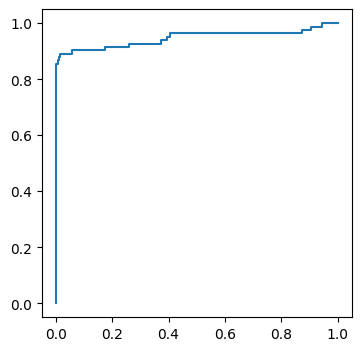

In [124]:
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr)
plt.show()

In [125]:
f"{np.divide(mlp_clf.score(X_train, y_train), mlp_clf.score(X_test, y_test))*100:.2f} %"

'100.05 %'